In [ ]:
import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe

# Episode length (in decisions) can never exceed Agent Max Step / Decision Period (5000/5, per
# BuildInfoWriter.cs output) - mlagents itself reports this as "999.000" for episodes that hit
# it, an off-by-one in its own counting. A symmetric mean±std band can still arithmetically
# exceed this (and go below 0) when the distribution is skewed/bimodal, even though no single
# episode ever does - used below to clamp episode-length ±std bands to a physically possible range.
EPISODE_LENGTH_CAP = 1000

# ── find all .out files under Assets/Agents ──────────────────────────────────
agents_dir = "Assets/Agents"
out_files = sorted(glob.glob(f"{agents_dir}/**/*.out", recursive=True))
print("Found runs:")
for i, f in enumerate(out_files):
    print(f"  [{i}] {f}")

In [ ]:
def _get(line, pattern, cast=float, default=0):
    """Extract a field from a log line; strips trailing period left by mlagents separator."""
    m = re.search(pattern, line)
    return cast(m.group(1).rstrip('.')) if m else cast(default)

def parse_out_file(filepath):
    """Parse an mlagents .out log into a list of dicts, one per summary line."""
    records = []
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if 'Mean Reward:' not in line:
                continue
            esc_match = re.search(r'Escalated: (\d+)/(\d+|\?)', line)
            records.append({
                'step':       _get(line, r'Step: (\d+)',                     int),
                'episodes':   _get(line, r'Episodes: (\d+)',                 int),
                'mean_r':     _get(line, r'Mean Reward: ([\-\d.]+)',         float),
                'std_r':      _get(line, r'Std of Reward: ([\d.]+)',         float),
                'mean_len':   _get(line, r'Mean Episode Length: ([\d.]+)',   float),
                'std_len':    _get(line, r'Std of Episode Length: ([\d.]+)', float),
                'goals':      _get(line, r'Goals: (\d+)',                    int),
                'terminated': _get(line, r'Terminated: (\d+)',               int),
                'maxstep':    _get(line, r'MaxStep: (\d+)',                  int),
                # Printed by the stats_patched.py ConsoleWriter patch once >=1 parallel
                # environment's rolling goal rate crosses terminal_penalty_escalation_goal_rate
                # (see carAgent.cs). Older runs predate this patch and simply never have the line.
                'escalated':       esc_match is not None,
                # Numerator/denominator of "Escalated: x/N". Denominator is None until
                # Custom/NumEnvs has been reported at least once (printed as "x/?" before that).
                'escalated_count': int(esc_match.group(1)) if esc_match else None,
                'escalated_total': int(esc_match.group(2)) if esc_match and esc_match.group(2) != '?' else None,
            })
    return records

# ── pick which run to plot (change index or hardcode a path) ─────────────────
RUN_INDEX = 2
filepath  = out_files[RUN_INDEX]
records   = parse_out_file(filepath)

print(f"Run : {os.path.basename(filepath)}")
print(f"Rows: {len(records)}")
print(f"Steps: {records[0]['step']:,} → {records[-1]['step']:,}")

In [25]:
# ── convert to numpy arrays ──────────────────────────────────────────────────
steps    = np.array([r['step']       for r in records])
episodes = np.array([r['episodes']   for r in records])
mean_r   = np.array([r['mean_r']     for r in records])
std_r    = np.array([r['std_r']      for r in records])
mean_len = np.array([r['mean_len']   for r in records])
std_len  = np.array([r['std_len']    for r in records])
goals    = np.array([r['goals']      for r in records])
term     = np.array([r['terminated'] for r in records])
maxstep  = np.array([r['maxstep']    for r in records])

# episodes that ended but weren't logged in any category
other    = np.maximum(0, episodes - goals - term - maxstep)

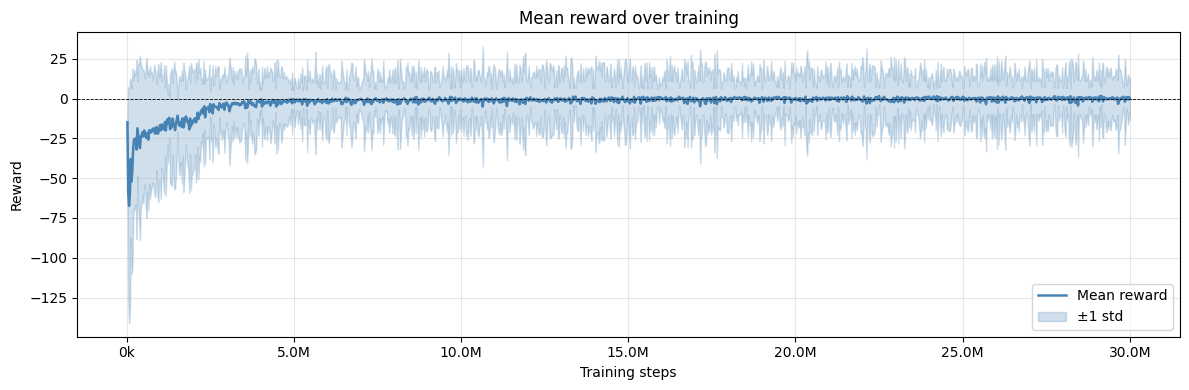

In [26]:
# ── Plot 1 : Mean Reward ± Std ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
ax.fill_between(steps,
                mean_r - std_r,
                mean_r + std_r,
                color='steelblue', alpha=0.25, label='±1 std')
ax.axhline(0, color='black', linewidth=0.6, linestyle='--')

ax.set_xlabel('Training steps')
ax.set_ylabel('Reward')
ax.set_title('Mean reward over training')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_reward.png', dpi=150)
plt.show()

In [ ]:
# ── Plot 2 : Episode count and mean episode length ───────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# top: episodes per summary interval
ax1.bar(steps, episodes, width=(steps[1]-steps[0])*0.8 if len(steps)>1 else 5000,
        color='slateblue', alpha=0.7, label='Episodes / interval')
ax1.set_ylabel('Episodes')
ax1.set_title('Episodes per summary interval')
ax1.legend()
ax1.grid(True, alpha=0.3)

# bottom: mean episode length ± std (band clamped to [0, EPISODE_LENGTH_CAP] - a symmetric
# mean±std band can otherwise imply an episode length that isn't physically possible)
ax2.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
ax2.fill_between(steps,
                 np.maximum(0, mean_len - std_len),
                 np.minimum(EPISODE_LENGTH_CAP, mean_len + std_len),
                 color='darkorange', alpha=0.25, label='±1 std')
ax2.set_xlabel('Training steps')
ax2.set_ylabel('Steps per episode')
ax2.set_title('Mean episode length over training')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_episodes.png', dpi=150)
plt.show()

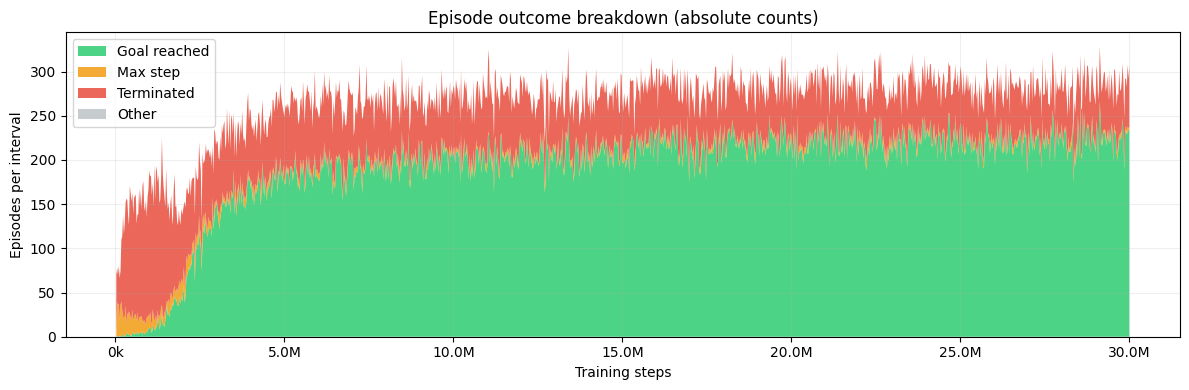

In [28]:
# ── Plot 3 : Episode outcomes ────────────────────────────────────────────────
#
# Three approaches — uncomment the one you prefer:
#
#  A) 100% stacked area  → shows proportion of each outcome over time
#                          best for seeing whether goal-rate is rising
#
#  B) Absolute stacked area → shows raw counts, height = total episodes
#                              good for seeing training throughput changes
#
#  C) Success-rate line  → single line: goals / episodes (0–1)
#                          cleanest way to track improvement

STYLE = 'B'   # change to 'B' or 'C'

COLORS = {
    'Goal':       '#2ecc71',   # green
    'MaxStep':    '#f39c12',   # orange
    'Terminated': '#e74c3c',   # red
    'Other':      '#bdc3c7',   # grey
}

fig, ax = plt.subplots(figsize=(12, 4))

if STYLE == 'A':
    total   = goals + term + maxstep + other
    total   = np.where(total == 0, 1, total)   # avoid /0
    g_pct   = goals   / total * 100
    ms_pct  = maxstep / total * 100
    t_pct   = term    / total * 100
    o_pct   = other   / total * 100

    ax.stackplot(steps,
                 g_pct, ms_pct, t_pct, o_pct,
                 labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                 colors=[COLORS['Goal'], COLORS['MaxStep'],
                         COLORS['Terminated'], COLORS['Other']],
                 alpha=0.85)
    ax.set_ylabel('% of episodes')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title('Episode outcome breakdown (proportions)')

elif STYLE == 'B':
    ax.stackplot(steps,
                 goals, maxstep, term, other,
                 labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                 colors=[COLORS['Goal'], COLORS['MaxStep'],
                         COLORS['Terminated'], COLORS['Other']],
                 alpha=0.85)
    ax.set_ylabel('Episodes per interval')
    ax.set_title('Episode outcome breakdown (absolute counts)')

elif STYLE == 'C':
    total        = np.where(episodes == 0, 1, episodes)
    success_rate = goals / total
    # smooth with a rolling window
    window       = max(1, len(success_rate) // 10)
    smoothed     = np.convolve(success_rate, np.ones(window)/window, mode='same')

    ax.plot(steps, success_rate, color=COLORS['Goal'], alpha=0.35, linewidth=1)
    ax.plot(steps, smoothed,     color=COLORS['Goal'], linewidth=2, label='Goal rate (smoothed)')
    ax.set_ylabel('Goals / total episodes')
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title('Goal success rate over training')

ax.set_xlabel('Training steps')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('plot_outcomes.png', dpi=150)
plt.show()

In [ ]:
# ── Combined figure : all three plots in one image ───────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)

ax_reward  = fig.add_subplot(gs[0, :])   # row 0, full width
ax_epcount = fig.add_subplot(gs[1, 0])   # row 1, left
ax_eplen   = fig.add_subplot(gs[1, 1])   # row 1, right
ax_outcome = fig.add_subplot(gs[2, :])   # row 2, full width

run_name = os.path.basename(filepath)
fig.suptitle(run_name, fontsize=11, color='grey')

step_fmt = mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'
)

# ── 1. Mean reward ± std ─────────────────────────────────────────────────────
ax_reward.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
ax_reward.fill_between(steps, mean_r - std_r, mean_r + std_r,
                        color='steelblue', alpha=0.25, label='±1 std')
ax_reward.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax_reward.set_ylabel('Reward')
ax_reward.set_title('Mean reward over training')
ax_reward.xaxis.set_major_formatter(step_fmt)
ax_reward.legend(fontsize=8)
ax_reward.grid(True, alpha=0.3)

# ── 2a. Episodes per interval ────────────────────────────────────────────────
bar_w = (steps[1] - steps[0]) * 0.8 if len(steps) > 1 else 5000
ax_epcount.bar(steps, episodes, width=bar_w, color='slateblue', alpha=0.7)
ax_epcount.set_ylabel('Episodes')
ax_epcount.set_title('Episodes per interval')
ax_epcount.xaxis.set_major_formatter(step_fmt)
ax_epcount.grid(True, alpha=0.3)

# ── 2b. Mean episode length ± std (band clamped to [0, EPISODE_LENGTH_CAP]) ──────────────
ax_eplen.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
ax_eplen.fill_between(steps,
                      np.maximum(0, mean_len - std_len),
                      np.minimum(EPISODE_LENGTH_CAP, mean_len + std_len),
                      color='darkorange', alpha=0.25, label='±1 std')
ax_eplen.set_ylabel('Steps per episode')
ax_eplen.set_title('Mean episode length')
ax_eplen.xaxis.set_major_formatter(step_fmt)
ax_eplen.legend(fontsize=8)
ax_eplen.grid(True, alpha=0.3)

# ── 3. Outcome breakdown (absolute stacked area — style B) ───────────────────
COLORS = {'Goal': '#2ecc71', 'MaxStep': '#f39c12', 'Terminated': '#e74c3c', 'Other': '#bdc3c7'}
ax_outcome.stackplot(
    steps,
    goals, maxstep, term, other,
    labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
    colors=[COLORS['Goal'], COLORS['MaxStep'], COLORS['Terminated'], COLORS['Other']],
    alpha=0.85,
)
ax_outcome.set_ylabel('Episodes per interval')
ax_outcome.set_title('Episode outcome breakdown (absolute counts)')
ax_outcome.xaxis.set_major_formatter(step_fmt)
ax_outcome.set_xlabel('Training steps')
ax_outcome.legend(loc='upper left', fontsize=8)
ax_outcome.grid(True, alpha=0.2)

plt.savefig('plot_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → plot_combined.png")

## Individual analysis: car_run_17811584 (esc0 / esc1), one set of plots per run

Unlike the interactive `RUN_INDEX`-based cells above (which overwrite the same `plot_*.png` files
each time), `analyze_single_run` below saves each run's plots with its own filename suffix so both
runs' outputs coexist side by side, and can be re-run independently.

In [ ]:
def _smooth(values, frac=0.1):
    """Edge-aware moving average - see training_comparison.ipynb for why plain
    np.convolve(mode='same') is biased near the array edges and how this avoids it."""
    window = max(1, int(len(values) * frac))
    kernel = np.ones(window) / window
    smoothed = np.convolve(values, kernel, mode='same')
    coverage = np.convolve(np.ones_like(values), kernel, mode='same')
    return smoothed / coverage

def _mark_escalation_steps_single(ax, escalated_step, escalated_all_step, color='black'):
    """Single-run version of training_comparison.ipynb's _mark_escalation_steps: marks the step
    where the terminal penalty first escalated (dash-dot line) and, with a distinct dotted line,
    the step where EVERY parallel environment has escalated (see carAgent.cs / stats_patched.py).
    Thin line + white halo so it stays visible without dominating the plot. Silently skips
    either marker if that step is unknown (predates the stats_patched.py logging, never
    escalated, or - for the "all" marker - never finished rolling out to every worker)."""
    y_top = ax.get_ylim()[1]
    if escalated_step is not None:
        ax.axvline(escalated_step, color=color, linestyle='-.', linewidth=1.1, zorder=5,
                   path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
        ax.text(escalated_step, y_top, '  esc first', rotation=90, va='top', ha='left',
                fontsize=7, color=color, fontweight='bold', zorder=6,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    if escalated_all_step is not None:
        ax.axvline(escalated_all_step, color=color, linestyle=':', linewidth=1.1, zorder=5,
                   path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
        ax.text(escalated_all_step, y_top, '  esc all', rotation=90, va='top', ha='left',
                fontsize=7, color=color, fontweight='bold', zorder=6,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])

def analyze_single_run(filepath, suffix):
    """Runs the same reward / episodes+length / outcomes / combined analysis as the cells
    above, for one .out file, saving each plot as plot_..._{suffix}.png so multiple runs'
    outputs don't overwrite each other. Reuses parse_out_file from cell 1."""
    records = parse_out_file(filepath)
    print(f"Run : {os.path.basename(filepath)}")
    print(f"Rows: {len(records)}")
    print(f"Steps: {records[0]['step']:,} -> {records[-1]['step']:,}")

    steps    = np.array([r['step']       for r in records])
    episodes = np.array([r['episodes']   for r in records])
    mean_r   = np.array([r['mean_r']     for r in records])
    std_r    = np.array([r['std_r']      for r in records])
    mean_len = np.array([r['mean_len']   for r in records])
    std_len  = np.array([r['std_len']    for r in records])
    goals    = np.array([r['goals']      for r in records])
    term     = np.array([r['terminated'] for r in records])
    maxstep  = np.array([r['maxstep']    for r in records])
    other    = np.maximum(0, episodes - goals - term - maxstep)

    # First step at which >=1 environment escalated, and first step at which EVERY
    # environment has escalated (count == total, once the denominator is known) - see
    # training_comparison.ipynb's to_arrays() for the same logic applied across runs.
    escalated_idx = next((i for i, r in enumerate(records) if r['escalated']), None)
    escalated_step = int(steps[escalated_idx]) if escalated_idx is not None else None
    escalated_all_idx = next(
        (i for i, r in enumerate(records)
         if r['escalated_total'] is not None and r['escalated_count'] == r['escalated_total']),
        None,
    )
    escalated_all_step = int(steps[escalated_all_idx]) if escalated_all_idx is not None else None

    step_fmt  = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
    COLORS    = {'Goal': '#2ecc71', 'MaxStep': '#f39c12', 'Terminated': '#e74c3c', 'Other': '#bdc3c7'}
    run_name  = os.path.basename(filepath)
    bar_w     = (steps[1] - steps[0]) * 0.8 if len(steps) > 1 else 5000

    # ── Plot 1: Mean Reward ± Std ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
    ax.fill_between(steps, mean_r - std_r, mean_r + std_r, color='steelblue', alpha=0.25, label='±1 std')
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_xlabel('Training steps')
    ax.set_ylabel('Reward')
    ax.set_title(f'Mean reward over training — {run_name}')
    ax.xaxis.set_major_formatter(step_fmt)
    ax.legend()
    ax.grid(True, alpha=0.3)
    _mark_escalation_steps_single(ax, escalated_step, escalated_all_step)
    plt.tight_layout()
    plt.savefig(f'plot_reward_{suffix}.png', dpi=150)
    plt.show()

    # ── Plot 2: Episode count and mean episode length ─────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax1.bar(steps, episodes, width=bar_w, color='slateblue', alpha=0.7, label='Episodes / interval')
    ax1.set_ylabel('Episodes')
    ax1.set_title(f'Episodes per summary interval — {run_name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
    ax2.fill_between(steps, np.maximum(0, mean_len - std_len),
                      np.minimum(EPISODE_LENGTH_CAP, mean_len + std_len),
                      color='darkorange', alpha=0.25, label='±1 std')
    ax2.set_xlabel('Training steps')
    ax2.set_ylabel('Steps per episode')
    ax2.set_title('Mean episode length over training')
    ax2.xaxis.set_major_formatter(step_fmt)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    _mark_escalation_steps_single(ax1, escalated_step, escalated_all_step)
    _mark_escalation_steps_single(ax2, escalated_step, escalated_all_step)
    plt.tight_layout()
    plt.savefig(f'plot_episodes_{suffix}.png', dpi=150)
    plt.show()

    # ── Plot 3: Episode outcomes (absolute stacked area — style B) ────────────
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.stackplot(steps, goals, maxstep, term, other,
                 labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                 colors=[COLORS['Goal'], COLORS['MaxStep'], COLORS['Terminated'], COLORS['Other']],
                 alpha=0.85)
    ax.set_ylabel('Episodes per interval')
    ax.set_title(f'Episode outcome breakdown — {run_name}')
    ax.set_xlabel('Training steps')
    ax.xaxis.set_major_formatter(step_fmt)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.2)
    _mark_escalation_steps_single(ax, escalated_step, escalated_all_step)
    plt.tight_layout()
    plt.savefig(f'plot_outcomes_{suffix}.png', dpi=150)
    plt.show()

    # ── Plot 4: Episode outcomes as separate lines (Goals / Terminated / MaxStep) ──
    # Same data as Plot 3, but each outcome as its own raw+smoothed line instead of a
    # stacked area - makes it easier to see e.g. whether Terminated is flat or trending
    # down, which a stacked area only shows as a hard-to-read band thickness.
    fig, ax = plt.subplots(figsize=(12, 4))
    for series, key, series_label in [
        (goals, 'Goal', 'Goal reached'),
        (term, 'Terminated', 'Terminated'),
        (maxstep, 'MaxStep', 'Max step'),
    ]:
        c = COLORS[key]
        ax.plot(steps, series, color=c, alpha=0.25, linewidth=1)
        ax.plot(steps, _smooth(series), color=c, linewidth=2, label=series_label)
    ax.set_ylabel('Episodes per interval')
    ax.set_title(f'Episode outcomes as separate lines — {run_name}')
    ax.set_xlabel('Training steps')
    ax.xaxis.set_major_formatter(step_fmt)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    _mark_escalation_steps_single(ax, escalated_step, escalated_all_step)
    plt.tight_layout()
    plt.savefig(f'plot_outcome_lines_{suffix}.png', dpi=150)
    plt.show()

    # ── Combined figure ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(14, 11))
    gs  = fig.add_gridspec(3, 2, hspace=0.45, wspace=0.35)
    ax_reward  = fig.add_subplot(gs[0, :])
    ax_epcount = fig.add_subplot(gs[1, 0])
    ax_eplen   = fig.add_subplot(gs[1, 1])
    ax_outcome = fig.add_subplot(gs[2, :])
    fig.suptitle(run_name, fontsize=11, color='grey')

    ax_reward.plot(steps, mean_r, color='steelblue', linewidth=1.8, label='Mean reward')
    ax_reward.fill_between(steps, mean_r - std_r, mean_r + std_r, color='steelblue', alpha=0.25, label='±1 std')
    ax_reward.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax_reward.set_ylabel('Reward')
    ax_reward.set_title('Mean reward over training')
    ax_reward.xaxis.set_major_formatter(step_fmt)
    ax_reward.legend(fontsize=8)
    ax_reward.grid(True, alpha=0.3)
    _mark_escalation_steps_single(ax_reward, escalated_step, escalated_all_step)

    ax_epcount.bar(steps, episodes, width=bar_w, color='slateblue', alpha=0.7)
    ax_epcount.set_ylabel('Episodes')
    ax_epcount.set_title('Episodes per interval')
    ax_epcount.xaxis.set_major_formatter(step_fmt)
    ax_epcount.grid(True, alpha=0.3)

    ax_eplen.plot(steps, mean_len, color='darkorange', linewidth=1.8, label='Mean length')
    ax_eplen.fill_between(steps, np.maximum(0, mean_len - std_len),
                           np.minimum(EPISODE_LENGTH_CAP, mean_len + std_len),
                           color='darkorange', alpha=0.25, label='±1 std')
    ax_eplen.set_ylabel('Steps per episode')
    ax_eplen.set_title('Mean episode length')
    ax_eplen.xaxis.set_major_formatter(step_fmt)
    ax_eplen.legend(fontsize=8)
    ax_eplen.grid(True, alpha=0.3)
    _mark_escalation_steps_single(ax_eplen, escalated_step, escalated_all_step)

    ax_outcome.stackplot(steps, goals, maxstep, term, other,
                          labels=['Goal reached', 'Max step', 'Terminated', 'Other'],
                          colors=[COLORS['Goal'], COLORS['MaxStep'], COLORS['Terminated'], COLORS['Other']],
                          alpha=0.85)
    ax_outcome.set_ylabel('Episodes per interval')
    ax_outcome.set_title('Episode outcome breakdown (absolute counts)')
    ax_outcome.xaxis.set_major_formatter(step_fmt)
    ax_outcome.set_xlabel('Training steps')
    ax_outcome.legend(loc='upper left', fontsize=8)
    ax_outcome.grid(True, alpha=0.2)
    _mark_escalation_steps_single(ax_outcome, escalated_step, escalated_all_step)

    savepath = f'plot_combined_{suffix}.png'
    plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {savepath}")

    return dict(steps=steps, episodes=episodes, mean_r=mean_r, std_r=std_r, mean_len=mean_len,
                std_len=std_len, goals=goals, term=term, maxstep=maxstep, other=other,
                escalated_step=escalated_step, escalated_all_step=escalated_all_step)

In [ ]:
data_17811584_0 = analyze_single_run('hpc/car_run_17811584_esc0/train_17811584_0.out', '17811584_0')

In [ ]:
data_17811584_1 = analyze_single_run('hpc/car_run_17811584_esc1/train_17811584_1.out', '17811584_1')

## Native (10k) vs bucketed (100k) resolution — side by side

`bucket_arrays` combines every `factor` consecutive summary-log rows into one. Counts
(`episodes`/`goals`/`term`/`maxstep`/`other`) are plain sums — exact, no approximation. The
mean/std fields (`mean_r`/`std_r`/`mean_len`/`std_len`) are *not* naively averaged, since each
row is already a per-window aggregate, not a raw value — averaging 10 window-means (or worse,
10 window-stds) would repeat the mean-of-means mistake this project has been careful to avoid
elsewhere. Instead:
- the combined mean is weighted by each window's episode count (`sum(n_i * mean_i) / sum(n_i)`),
  which is exactly the true overall mean;
- the combined variance uses the pooled-variance identity `total variance = weighted average of
  within-window variances + weighted variance of window means`, matching the population-std
  (`ddof=0`) convention mlagents itself uses for `Std of Reward`/`Std of Episode Length`.

Both are exact given the per-window count/mean/std already in the log - no information is lost
beyond the time resolution itself.

In [ ]:
_STEP_FMT = mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
_COLORS = {'Goal': '#2ecc71', 'MaxStep': '#f39c12', 'Terminated': '#e74c3c', 'Other': '#bdc3c7'}

def bucket_arrays(d, factor):
    """Combines every `factor` consecutive summary-log rows into one, e.g. factor=10 turns
    10k-step windows into 100k-step windows. Counts (episodes/goals/term/maxstep/other) are
    summed - exact. mean_r/mean_len are combined via an episode-count-weighted average (the
    true overall mean); std_r/std_len via the pooled-variance identity (total variance =
    weighted-average within-window variance + weighted variance of window means) - both exact
    given the per-window count/mean/std already in the log, not an approximation. Naively
    averaging window-means or window-stds would be wrong (mean-of-means). steps takes the last
    raw step in each bucket (Step is cumulative). escalated_step/escalated_all_step are absolute
    markers and pass through unchanged."""
    n = len(d['steps'])
    n_buckets = int(np.ceil(n / factor))
    steps_b, episodes_b, goals_b, term_b, maxstep_b, other_b = [], [], [], [], [], []
    mean_r_b, std_r_b, mean_len_b, std_len_b = [], [], [], []

    for i in range(n_buckets):
        sl = slice(i * factor, (i + 1) * factor)
        ep = d['episodes'][sl]
        total_ep = ep.sum()

        steps_b.append(d['steps'][sl][-1])
        episodes_b.append(total_ep)
        goals_b.append(d['goals'][sl].sum())
        term_b.append(d['term'][sl].sum())
        maxstep_b.append(d['maxstep'][sl].sum())
        other_b.append(d['other'][sl].sum())

        if total_ep > 0:
            m, s = d['mean_r'][sl], d['std_r'][sl]
            overall_mean = np.sum(ep * m) / total_ep
            overall_var = np.sum(ep * (s ** 2 + (m - overall_mean) ** 2)) / total_ep
            mean_r_b.append(overall_mean)
            std_r_b.append(np.sqrt(overall_var))

            m2, s2 = d['mean_len'][sl], d['std_len'][sl]
            overall_mean2 = np.sum(ep * m2) / total_ep
            overall_var2 = np.sum(ep * (s2 ** 2 + (m2 - overall_mean2) ** 2)) / total_ep
            mean_len_b.append(overall_mean2)
            std_len_b.append(np.sqrt(overall_var2))
        else:
            mean_r_b.append(0.0); std_r_b.append(0.0)
            mean_len_b.append(0.0); std_len_b.append(0.0)

    return dict(
        steps=np.array(steps_b), episodes=np.array(episodes_b),
        mean_r=np.array(mean_r_b), std_r=np.array(std_r_b),
        mean_len=np.array(mean_len_b), std_len=np.array(std_len_b),
        goals=np.array(goals_b), term=np.array(term_b), maxstep=np.array(maxstep_b),
        other=np.array(other_b),
        escalated_step=d.get('escalated_step'), escalated_all_step=d.get('escalated_all_step'),
    )

def plot_native_vs_bucketed(d, factors, run_name, kind='outcome_lines', savepath=None):
    """Side-by-side comparison: native (per-summary_freq-window) resolution plus one panel per
    entry in `factors` (e.g. [10, 100] -> 100k-step and 1M-step buckets alongside native), so
    you can directly judge which resolution is most legible. kind picks which plot to render
    this way: 'outcome_lines' (Goals/Terminated/MaxStep as separate lines, smoothed) or
    'reward' (mean reward ± std, raw per-window value - no smoothing)."""
    panels = [(d, f'native ({len(d["steps"])} points)')]
    for factor in factors:
        d_bucket = bucket_arrays(d, factor)
        panels.append((d_bucket, f'bucketed x{factor} ({len(d_bucket["steps"])} points)'))

    fig, axes = plt.subplots(1, len(panels), figsize=(8 * len(panels), 4.5), sharey=True)
    for ax, (dd, label) in zip(axes, panels):
        if kind == 'outcome_lines':
            for series, key, series_label in [
                (dd['goals'], 'Goal', 'Goal reached'),
                (dd['term'], 'Terminated', 'Terminated'),
                (dd['maxstep'], 'MaxStep', 'Max step'),
            ]:
                c = _COLORS[key]
                ax.plot(dd['steps'], series, color=c, alpha=0.25, linewidth=1)
                ax.plot(dd['steps'], _smooth(series), color=c, linewidth=2, label=series_label)
            ax.set_ylabel('Episodes per interval')
        elif kind == 'reward':
            ax.fill_between(dd['steps'], dd['mean_r'] - dd['std_r'], dd['mean_r'] + dd['std_r'],
                             color='steelblue', alpha=0.15, linewidth=0)
            ax.plot(dd['steps'], dd['mean_r'], color='steelblue', linewidth=1.2, label='Mean reward')
            ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
            ax.set_ylabel('Mean reward')
        ax.set_title(f'{run_name} — {label}', fontsize=10)
        ax.set_xlabel('Training steps')
        ax.xaxis.set_major_formatter(_STEP_FMT)
        ax.grid(True, alpha=0.3)
        _mark_escalation_steps_single(ax, dd['escalated_step'], dd['escalated_all_step'])
    axes[-1].legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches='tight')
    plt.show()

for label, data in [('17811584_0', data_17811584_0), ('17811584_1', data_17811584_1)]:
    plot_native_vs_bucketed(data, [10, 100], label, kind='outcome_lines',
                             savepath=f'plot_outcome_lines_native_vs_bucketed_{label}.png')
    plot_native_vs_bucketed(data, [10, 100], label, kind='reward',
                             savepath=f'plot_reward_native_vs_bucketed_{label}.png')